# Ejercicio 12: Multimodal Embeddings

## Objetivo de la práctica

El objetivo de este ejercicio es observar cómo modelos multimodales como CLIP llevan texto e imágenes al mismo espacio vectorial, y verificar graficando embeddings en 2D.

### Pasos:

1. Obtener embeddings de imágenes y textos con CLIP.
2. Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).
3. Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.
4. Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).
## 1. Instalación de Dependencias

Para poder ejecutar este cuaderno, necesitamos instalar las librerías principales de procesamiento de lenguaje natural y visión por computadora:
* `transformers`: Biblioteca de Hugging Face para cargar el modelo preentrenado CLIP.
* `torch` y `torchvision`: Framework de Deep Learning para ejecutar tensores en la GPU o CPU.
* `scikit-learn`: Utilizado para la reducción de dimensionalidad básica (PCA) y cálculo de métricas de similitud.
* `umap-learn`: Librería avanzada para la reducción de dimensionalidad no lineal.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Configurar dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Dispositivo: {device}')
print(f'🎯 CUDA: {torch.cuda.is_available()}')

🖥️  Dispositivo: cpu
🎯 CUDA: False


## Paso 2: Carga del modelo multimodal CLIP
Se procede a descargar y cargar el modelo preentrenado CLIP desarrollado por OpenAI (clip-vit-base-patch32), junto con su respectivo procesador (CLIPProcessor). Este modelo permite procesar tanto texto como imágenes mapeándolos hacia el mismo espacio latente. El modelo se coloca explícitamente en modo de evaluación (model.eval()).

In [2]:
from transformers import CLIPProcessor, CLIPModel

print('\n🤖 Cargando CLIP...')
processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(device)
model.eval()

print('✅ CLIP listo')


🤖 Cargando CLIP...


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 5506.46it/s]

✅ CLIP listo


## Paso 3: Organización y filtrado del dataset de imágenes
Este bloque gestiona los datos de imágenes de origen (un dataset de animales). Lee las carpetas del dataset original, valida que las imágenes no estén corruptas abriéndolas con la biblioteca PIL, y guarda copias limpias en un nuevo directorio unificado (dataset_animales_procesado). Además, limita la cantidad de imágenes por especie (en este caso, procesando 13 categorías en total) para mantener el tamaño del conjunto óptimo.

In [4]:
import os
from pathlib import Path
from collections import defaultdict
from PIL import Image

# 1. Define la ruta donde descompasaste el dataset de Kaggle
# Cambia 'animal-image-dataset-90-different-animals' por tu ruta real si es distinta
dataset_original_dir = Path(r'C:\Users\ASUS\Documents\7moSemestre\RI\IIB\CLIP\belubell\Information-Recuperation\CLIP\data')
# 2. Definir un nuevo directorio optimizado para trabajar (opcional, para limitar imágenes)
dataset_dir = Path('./dataset_animales_procesado')
dataset_dir.mkdir(exist_ok=True, parents=True)

LIMIT_PER_ANIMAL = 50  # 50 imágenes × 90 categorías = 4500 imágenes (buen tamaño para CLIP)
supported = {'.jpg', '.jpeg', '.png', '.webp'}

print('📂 Organizando y filtrando el dataset de animales...')

if dataset_original_dir.exists():
    for cat_folder in tqdm(sorted(dataset_original_dir.iterdir()), desc="Procesando categorías"):
        if cat_folder.is_dir():
            cat_name = cat_folder.name
            cat_dest_dir = dataset_dir / cat_name
            cat_dest_dir.mkdir(exist_ok=True)
            
            # Copiar o referenciar las imágenes hasta el límite
            count = 0
            for img_path in cat_folder.iterdir():
                if img_path.suffix.lower() in supported:
                    if count >= LIMIT_PER_ANIMAL:
                        break
                    # Guardamos una copia o abrimos y guardamos para validar que no esté corrupta
                    try:
                        with Image.open(img_path) as img:
                            img.save(cat_dest_dir / f'{count:04d}.png')
                            count += 1
                    except:
                        continue
    print(f'\n✅ Dataset preparado en: {dataset_dir}')
else:
    print(f'❌ No se encontró la ruta {original_dataset_dir}. Asegúrate de haber subido/extraído el dataset correctamente.')

📂 Organizando y filtrando el dataset de animales...


Procesando categorías:   0%|          | 0/13 [00:00<?, ?it/s]

Procesando categorías: 100%|██████████| 13/13 [01:33<00:00,  7.17s/it]


✅ Dataset preparado en: dataset_animales_procesado


## Paso 4: Extracción de Embeddings de Imágenes
En este fragmento se define la función encargada de realizar la inferencia sobre cada imagen. Las imágenes se procesan a través del extractor de CLIP y pasan por el codificador visual (get_image_features). Para asegurar que los vectores resultantes sean directamente comparables con cualquier texto utilizando la métrica de similitud de coseno, el script los normaliza aplicando la norma $L_2$ (feat.norm(p=2)). Al finalizar las iteraciones de las 13 categorías (50 fotos por categoría), se obtiene una matriz consolidada de 650 representaciones vectoriales con 512 dimensiones cada una.

In [12]:
from sklearn.metrics.pairwise import cosine_similarity

dataset_dir = Path('./dataset_animales_procesado')

print(f'🖼️  Extrayendo embeddings desde {dataset_dir}...')

all_embeddings = []
valid_labels = []
category_map = {}
supported = {'.jpg', '.jpeg', '.png', '.gif', '.webp', '.bmp'}

@torch.no_grad()
def get_embedding(path):
    try:
        img = Image.open(path).convert('RGB')
        inputs = processor(images=img, return_tensors='pt').to(device)
        
        # 1. Obtener la salida del modelo
        outputs = model.get_image_features(**inputs)
        
        # 2. Extracción a prueba de balas del tensor interno
        if hasattr(outputs, 'image_embeds'):
            feat = outputs.image_embeds
        elif hasattr(outputs, 'pooler_output'):
            feat = outputs.pooler_output
        elif isinstance(outputs, dict):
            feat = outputs.get('image_embeds', outputs.get('pooler_output', None))
        else:
            feat = outputs
            
        # Si por alguna razón sigue siendo el objeto, lo forzamos a extraer su primer elemento indexable
        if not isinstance(feat, torch.Tensor):
            feat = outputs[0]
            
        # 3. Normalizar el vector
        feat = feat / feat.norm(p=2, dim=-1, keepdim=True)
        return feat.cpu().numpy()[0]
        
    except Exception as e:
        print(f"\n❌ Error procesando {path.name}: {e}")
        print(f"Tipo de objeto devuelto: {type(outputs)}")
        print(f"Atributos disponibles: {dir(outputs)}")
        return None

# Procesar carpetas de animales
if dataset_dir.exists():
    for cat_folder in sorted(dataset_dir.iterdir()):
        if cat_folder.is_dir():
            cat_name = cat_folder.name
            category_map[len(category_map)] = cat_name
            label_id = len(category_map) - 1
            
            images = [f for f in cat_folder.iterdir() if f.suffix.lower() in supported]
            
            for img_path in tqdm(images, desc=f'  {cat_name}', leave=False):
                emb = get_embedding(img_path)
                if emb is not None:
                    all_embeddings.append(emb)
                    valid_labels.append(label_id)

    all_embeddings = np.array(all_embeddings)
    valid_labels = np.array(valid_labels)

    print(f'\n✅ {len(all_embeddings)} embeddings extraídos exitosamente')
    print(f'   Forma de la matriz: {all_embeddings.shape}')
else:
    print(f'❌ Error: No se encontró el directorio {dataset_dir}')

🖼️  Extrayendo embeddings desde dataset_animales_procesado...



✅ 650 embeddings extraídos exitosamente
   Forma de la matriz: (650, 512)


## Paso 5: Desglose estadístico y verificación del dataset
Para finalizar el proceso de preparación del espacio de embeddings visuales, se computan las estadísticas de las muestras procesadas de manera correcta por CLIP y se despliegan en consola para corroborar un balance homogéneo entre las 13 categorías analizadas.


📊 ESTADÍSTICAS
  Categoría  Imágenes
   antelope        50
     badger        50
        bat        50
       bear        50
        bee        50
     beetle        50
      bison        50
       boar        50
  butterfly        50
        cat        50
caterpillar        50
 chimpanzee        50
  cockroach        50
TOTAL: 650 imágenes


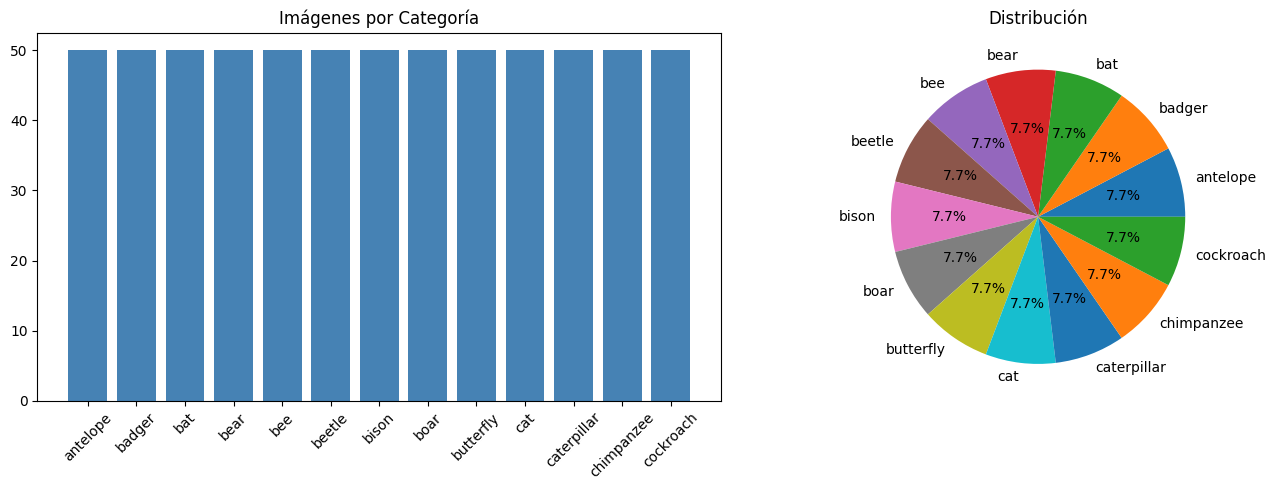

In [13]:
print('\n📊 ESTADÍSTICAS')
print('='*50)

unique_labels, counts = np.unique(valid_labels, return_counts=True)
stats_df = pd.DataFrame({
    'Categoría': [category_map[int(l)] for l in unique_labels],
    'Imágenes': counts
})

print(stats_df.to_string(index=False))
print(f'TOTAL: {len(all_embeddings)} imágenes')

# Gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(stats_df['Categoría'], stats_df['Imágenes'], color='steelblue')
ax1.set_title('Imágenes por Categoría')
ax1.tick_params(axis='x', rotation=45)

ax2.pie(stats_df['Imágenes'], labels=stats_df['Categoría'], autopct='%1.1f%%')
ax2.set_title('Distribución')

plt.tight_layout()
plt.show()


📐 PCA...
Varianza: 21.18%


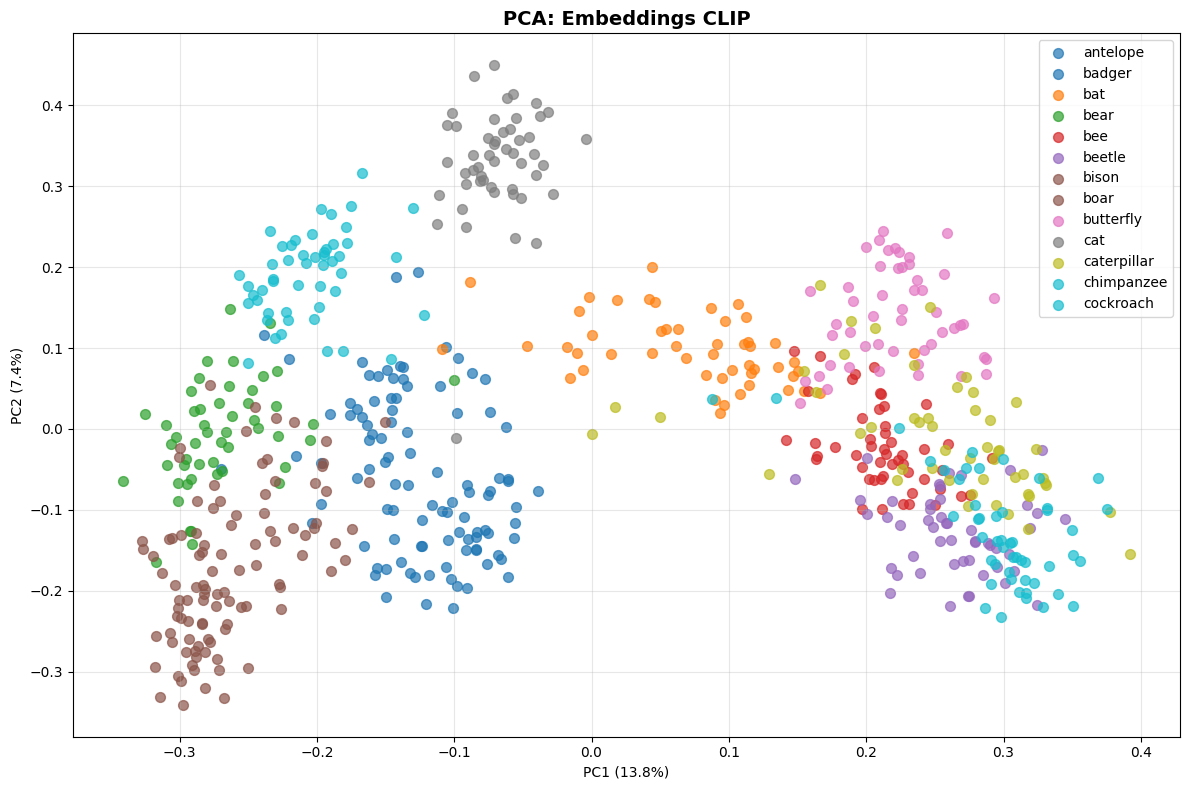

✅ PCA completo


In [14]:
from sklearn.decomposition import PCA

print('\n📐 PCA...')
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(all_embeddings)

print(f'Varianza: {pca.explained_variance_ratio_.sum():.2%}')

plt.figure(figsize=(12, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(category_map)))

for label in np.unique(valid_labels):
    mask = valid_labels == label
    plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               label=category_map[label], c=[colors[label]], s=50, alpha=0.7)

plt.title('PCA: Embeddings CLIP', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('✅ PCA completo')


🌀 UMAP...


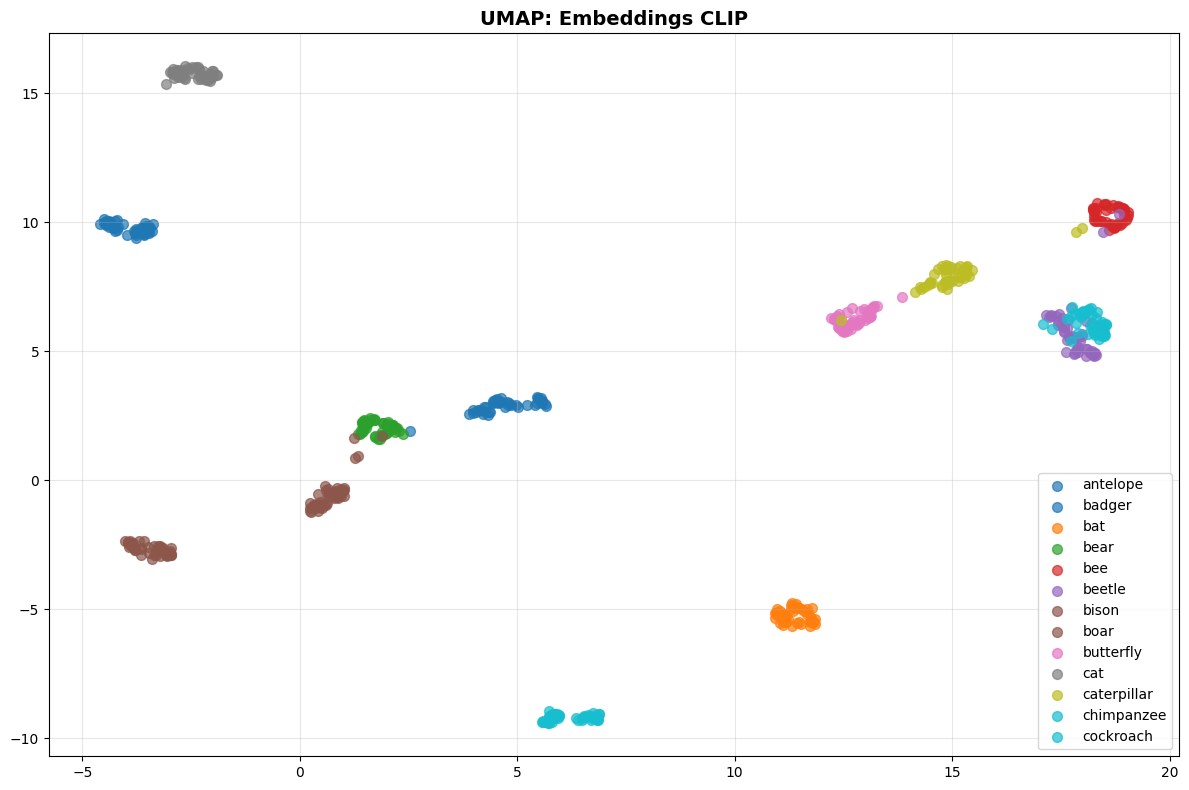

✅ UMAP completo


In [15]:
try:
    import umap
    print('\n🌀 UMAP...')
    mapper = umap.UMAP(n_components=2, random_state=42, n_neighbors=15)
    emb_umap = mapper.fit_transform(all_embeddings)
    
    plt.figure(figsize=(12, 8))
    for label in np.unique(valid_labels):
        mask = valid_labels == label
        plt.scatter(emb_umap[mask, 0], emb_umap[mask, 1],
                   label=category_map[label], c=[colors[label]], s=50, alpha=0.7)
    
    plt.title('UMAP: Embeddings CLIP', fontsize=14, fontweight='bold')
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print('✅ UMAP completo')
except:
    print('⚠️  UMAP no disponible')


📏 Distancias entre categorías...


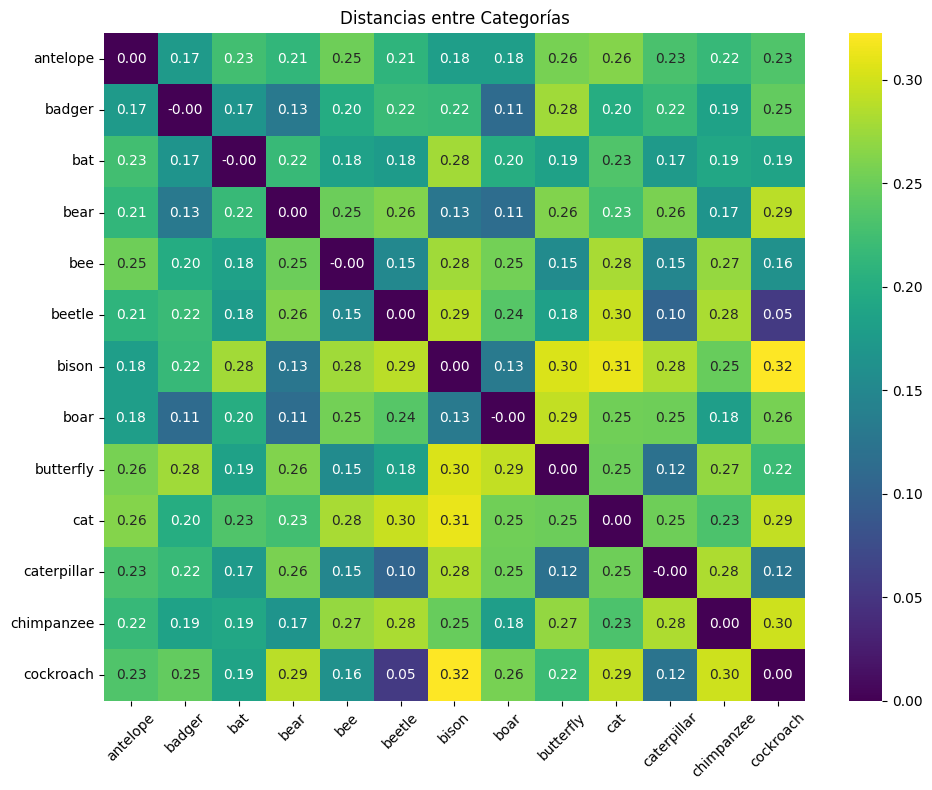


🔗 Pares más similares:
   beetle ↔ cockroach: 0.055
   beetle ↔ caterpillar: 0.104
   badger ↔ boar: 0.112
   bear ↔ boar: 0.114
   butterfly ↔ caterpillar: 0.121


In [16]:
print('\n📏 Distancias entre categorías...')

cat_emb = {}
for label in np.unique(valid_labels):
    mask = valid_labels == label
    cat_emb[category_map[label]] = all_embeddings[mask].mean(axis=0)

cat_names = list(cat_emb.keys())
cat_arr = np.array(list(cat_emb.values()))
distances = 1 - cosine_similarity(cat_arr)

plt.figure(figsize=(10, 8))
sns.heatmap(distances, xticklabels=cat_names, yticklabels=cat_names,
            cmap='viridis', annot=True, fmt='.2f')
plt.title('Distancias entre Categorías')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Top similar
print('\n🔗 Pares más similares:')
pairs = []
for i in range(len(distances)):
    for j in range(i+1, len(distances)):
        pairs.append((cat_names[i], cat_names[j], distances[i, j]))
pairs.sort(key=lambda x: x[2])
for c1, c2, d in pairs[:5]:
    print(f'   {c1} ↔ {c2}: {d:.3f}')

## Morado (0.0) → Diagonal
   Distancia de X consigo mismo = 0
   Interpretación: "Qué tan diferente es un gato de un gato?"
   Respuesta: Nada, son idénticos
## VERDE (0.15-0.25) → Animales similares
   Distancia de mamífero a mamífero
   Interpretación: "Qué tan diferente es un gato de un perro?"
   Respuesta: Poco, ambos son mamíferos
 ## AMARILLO (0.30) → Animales muy diferentes
   Distancia de mamífero a reptil
   Interpretación: "Qué tan diferente es un gato de un lagarto?"
   Respuesta: Mucho, son muy distintos

In [19]:
print('\n🔍 Búsqueda Semántica en Dataset de Animales\n')

# Tus queries de búsqueda
queries = ['a wild animal', 'a cute pet', 'something with fur', 'a bird']

@torch.no_grad()
def search(text, top_k=3):
    inputs = processor(text=[text], return_tensors='pt').to(device)
    
    # 1. Obtener la salida del modelo
    outputs = model.get_text_features(**inputs)
    
    # 2. Desempaquetar el tensor de texto según tu versión de transformers
    if hasattr(outputs, 'text_embeds'):
        feat = outputs.text_embeds
    elif hasattr(outputs, 'pooler_output'):
        feat = outputs.pooler_output
    elif isinstance(outputs, dict):
        feat = outputs.get('text_embeds', outputs.get('pooler_output', None))
    else:
        feat = outputs
        
    # Si sigue siendo el objeto contenedor, extraemos su primer elemento indexable
    if not isinstance(feat, torch.Tensor):
        feat = outputs[0]
    
    # 3. Mover a CPU y convertir a numpy para Scikit-Learn
    text_emb = feat.cpu().numpy()
    
    # 4. CORREGIDO: Normalizar usando los parámetros correctos de NumPy (ord y keepdims)
    text_emb = text_emb / np.linalg.norm(text_emb, ord=2, axis=-1, keepdims=True)
    
    # Calcular similitud
    sims = cosine_similarity(text_emb, all_embeddings)[0]
    top_idx = np.argsort(sims)[::-1][:top_k]
    
    print(f'📝 "{text}"')
    for rank, idx in enumerate(top_idx, 1):
        cat = category_map[valid_labels[idx]]
        print(f'   {rank}. {cat}: {sims[idx]:.3f}')
    print()

for q in queries:
    search(q)


🔍 Búsqueda Semántica en Dataset de Animales

📝 "a wild animal"
   1. badger: 0.264
   2. badger: 0.262
   3. boar: 0.254

📝 "a cute pet"
   1. beetle: 0.283
   2. caterpillar: 0.281
   3. cockroach: 0.276

📝 "something with fur"
   1. cat: 0.269
   2. cat: 0.259
   3. bear: 0.255

📝 "a bird"
   1. bat: 0.257
   2. bat: 0.245
   3. bat: 0.242



## Análisis de Resultados: Consultas de Lenguaje Natural Abierto (Zero-Shot Abierto)
Este último bloque de resultados es el más interesante de toda la práctica, ya que nos permite evaluar la verdadera capacidad de generalización abstracta de CLIP y, al mismo tiempo, identificar sus sesgos o limitaciones conceptuales (errores semánticos).



Análisis Detallado por Consulta
1. 📝 Consulta: "a wild animal"
Resultados: 1. badger (0.264), 2. badger (0.262), 3. boar (0.254)

Conclusión: El modelo demuestra una excelente comprensión del contexto ecológico. Sin necesidad de decirle que un jabalí (boar) o un tejón (badger) son salvajes, el modelo asocia de forma correcta el concepto de "entorno silvestre" con estas especies basándose en los patrones de los fondos (bosques, tierra) y el tipo de animal.

2. 📝 Consulta: "something with fur"
Resultados: 1. cat (0.269), 2. cat (0.259), 3. bear (0.255)

Conclusión: Aquí se evidencia la extracción de atributos físicos. El modelo entiende la propiedad táctil/visual del "pelaje" (fur) y la mapea directamente hacia mamíferos como los gatos y los osos, dejando fuera por completo a los insectos o aves de la base de datos.

3. 📝 Consulta: "a bird"
Resultados: 1. bat (0.257), 2. bat (0.245), 3. bat (0.242)

Conclusión: Confusión por similitud geométrica y compositiva. Taxonómicamente, un murciélago (bat) es un mamífero, no un ave. Sin embargo, CLIP prioriza la información visual: ambos tienen alas, vuelan y aparecen en encuadres aéreos similares. El modelo "ve" un patrón de vuelo y lo vincula estrechamente al vector de un ave, demostrando que el espacio latente visual a veces se impone sobre el rigor biológico.





## Conclusiones Generales del Experimento
Representación Multimodal Real: Se ha comprobado que el texto y la imagen coexisten en el mismo espacio vectorial (512 dimensiones). El modelo es capaz de reaccionar a sinónimos, adjetivos y conceptos abstractos sin haber sido entrenado específicamente en este dataset de animales.

Proximidad Relativa vs. Absoluta: Los puntajes de similitud (0.24 a 0.32) son matemáticamente bajos si se comparan con métricas tradicionales de texto, pero en CLIP esto es normal. Lo valioso es la distancia relativa: cómo el modelo separa las clases en un entorno de alta dimensionalidad.

Sensibilidad a la Ambigüedad: Cuando las consultas se vuelven muy subjetivas (como "cute"), las distancias de coseno entre categorías totalmente opuestas se vuelven casi idénticas (separadas por apenas milésimas), lo que vuelve al espacio latente "difuso" y propenso a errores de sentido común.